### Install dependencies
Install the `unsloth` library, which provides fast, memory-efficient fine-tuning utilities for vision-language models like Llama 3.2 Vision.

In [ ]:
!pip install unsloth --quiet

### Imports
Load the core libraries: `unsloth` for the vision model wrapper, `torch` for tensor operations, `datasets` for loading the radiology dataset, and `TextStreamer` for streaming generated text token-by-token.

In [ ]:
import os
from unsloth import FastVisionModel, is_bf16_supported
import torch
from datasets import load_dataset
from transformers import TextStreamer
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

### Load the base model
Download and load the pretrained `Llama-3.2-11B-Vision-Instruct` model in 4-bit quantization, along with its tokenizer, to keep memory usage low.

In [ ]:
model,tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Llama-3.2-11B-Vision-Instruct",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

### Configure LoRA fine-tuning
Wrap the base model with LoRA (Low-Rank Adaptation) adapters so only a small number of parameters are trained, across both the vision and language layers.

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers = True,
    finetune_language_layers = True,
    finetune_attention_modules = True,
    finetune_mlp_modules = True,
    r = 8,
    lora_alpha = 16,
    lora_dropout = 0.1,
    bias = "none",
    random_state = 42,
    use_rslora = False,
    loftq_config = None,
)

### Load the radiology dataset
Load the `Radiology_mini` dataset (image + caption pairs) and define the instruction prompt that will be used to ask the model to describe each radiograph.

In [ ]:
dataset = load_dataset("unsloth/Radiology_mini",split = "train")
instruction = "You are an expert radiographer, Describe accurately what you see in this image."

### Format samples as chat conversations
Define a helper that converts each `(image, caption)` sample into the chat-style message format the model expects, with a user turn (image + instruction) and an assistant turn (the target caption).

In [ ]:
def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["caption"]} ]
        },
    ]
    return { "messages" : conversation }
pass

### Build the training dataset
Apply the conversion function across the full dataset to produce the list of chat-formatted training examples.

In [ ]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

#### Before training how the model performs on the dataset

Let's first prepare a single example and build the model inputs, so we can see how the untrained model performs before any fine-tuning.

In [ ]:
FastVisionModel.for_inference(model)
image = dataset[0]["image"]
instruction = "You are an expert radiographer.Describe accurately what you see in the image."


messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]

input_text = tokenizer.apply_chat_template(messages,add_generation_prompt=True)

inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt"
).to("cuda")

Suppress noisy `UserWarning`s that can clutter the generation output.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

Generate and stream the caption token-by-token so we can see the base model's raw output on this radiograph before fine-tuning.

In [ ]:
text_streamer = TextStreamer(tokenizer,skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)


**Step 1: Overall Features**

The image appears to be a panoramic radiograph of a jawbone in the mandible.

* It may also be considered a panoramic radiographic view of the jaw with an emphasis on the upper molars
* It can also be interpreted as a panoramic view of the mandible

**Step 2: Detailed Analysis**

* The most notable feature is that a significant amount of tooth material is missing.
* This includes some teeth that may have fallen out or broken off completely, and others that are only partially visible with some crown structures missing
* These teeth may appear to have been extracted and left behind


#### Training


### Set up the trainer
Switch the model into training mode and configure an `SFTTrainer` (supervised fine-tuning trainer) with the vision-aware data collator, batch size, learning rate, and other training hyperparameters.

In [ ]:
from unsloth import FastVisionModel, is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)  # Enable training mode

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),  # Must use!
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,
        learning_rate = 2e-4,
        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # Set to "wandb" if you want logging
        remove_unused_columns = False,
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 4,
        max_length = 2048,      # renamed from max_seq_length in SFTConfig
    ),
)

Record starting GPU memory usage so we can measure how much memory the fine-tuning run consumes.

In [ ]:
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

### Run fine-tuning
Kick off the actual training loop. This fine-tunes the LoRA adapters on the radiology captioning task.

In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'bos_token_id': 128000}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,978 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 33,587,200 of 10,703,808,035 (0.31% trained)


Step,Training Loss
1,3.669132
2,3.706135
3,3.339279
4,3.036916
5,2.692852
6,2.627759
7,2.221855
8,2.056625
9,1.785645
10,1.453313


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-30/tokenizer_config.json.


Report GPU memory usage and training time statistics from the run above.

In [ ]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory         /max_memory*100, 3)
lora_percentage = round(used_memory_for_lora/max_memory*100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

1019.5162 seconds used for training.
16.99 minutes used for training.
Peak reserved memory = 11.404 GB.
Peak reserved memory for training = 2.103 GB.
Peak reserved memory % of max memory = 78.308 %.
Peak reserved memory for training % of max memory = 14.441 %.


### After training

Display the sample radiograph we've been using throughout, for visual reference before comparing the model's before/after captions.

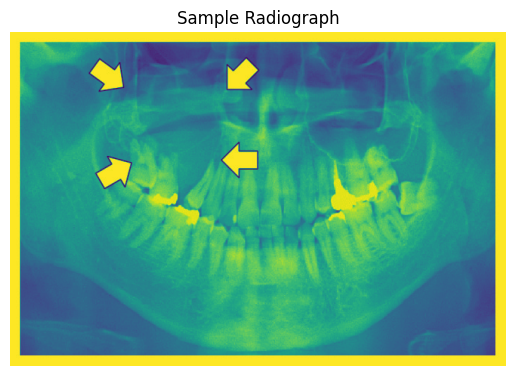

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis("off")
plt.title("Sample Radiograph")
plt.show()

Now run the same image and instruction through the **fine-tuned** model and stream its caption, so we can qualitatively compare it to the "before" output above.

In [ ]:
print("\nAfter training:\n")
FastVisionModel.for_inference(model)
image = dataset[0]["image"]
instruction = "You are an expert radiographer. Describe accurately what you see in this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)


After training:

Panoramic radiography demonstrating the presence of multiple dentigerous cysts involving the bilateral anterior maxilla and mandible, with tooth #4 ectopic eruption. The bilateral odontomas appear as large radiolucent lesions (arrows). The ectopic eruption of the 4 is more prominent.<|eot_id|>


## Evaluation: Comparing Before vs After Fine-tuning

Now that we've generated a caption **after** fine-tuning, let's put this on a proper footing.
We'll run both the **base (pre-fine-tuning)** model and the **fine-tuned** model over a held-out
sample of the dataset, compare the generated captions to the ground-truth radiology captions, and
score them with a handful of standard NLG (natural-language generation) metrics:

- **BLEU** — n-gram precision overlap (higher = closer wording to reference)
- **ROUGE-1 / ROUGE-2 / ROUGE-L** — recall-oriented n-gram / longest-common-subsequence overlap
- **METEOR** — accounts for stemming/synonym matches, correlates better with human judgment than BLEU
- **BERTScore (F1)** — embedding-based semantic similarity, robust to paraphrasing

We'll then visualize the score distributions and the before/after comparison as plots.

In [ ]:
!pip install --quiet evaluate rouge_score nltk bert_score pandas
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

### Helper function to generate a caption (no streaming, returns text)

In [ ]:
def generate_caption(model, tokenizer, image, instruction, max_new_tokens=128):
    """Runs inference on a single image and returns the decoded caption text
    (no streaming — we need the raw string for scoring)."""
    FastVisionModel.for_inference(model)

    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": instruction}
        ]}
    ]
    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        use_cache=True,
        temperature=0.5,
        min_p=0.1,
        pad_token_id=tokenizer.tokenizer.eos_token_id if hasattr(tokenizer, "tokenizer") else tokenizer.eos_token_id,
    )

    # Only decode the newly generated tokens (strip the prompt back off)
    generated_tokens = output_ids[:, inputs["input_ids"].shape[1]:]
    caption = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0].strip()
    return caption

### Generate predictions on a sample of the dataset

To keep this fast, we evaluate on a small held-out sample (adjust `N_EVAL_SAMPLES` for a
larger/smaller run). For each sample we store the ground-truth caption, plus the caption
generated by the fine-tuned model. If you also have the base model's outputs saved from the
"Before training" section, they'll be reused; otherwise we regenerate them here for a fair
side-by-side comparison.

In [ ]:
import random

N_EVAL_SAMPLES = 25  # increase for a more robust evaluation (slower)
eval_instruction = "You are an expert radiographer. Describe accurately what you see in this image."

random.seed(42)
eval_indices = random.sample(range(len(dataset)), min(N_EVAL_SAMPLES, len(dataset)))

references = []      # ground-truth captions
after_predictions = []   # fine-tuned model outputs

FastVisionModel.for_inference(model)  # ensure fine-tuned model is in inference mode

for idx in eval_indices:
    sample = dataset[idx]
    ref_caption = sample["caption"]
    pred_caption = generate_caption(model, tokenizer, sample["image"], eval_instruction)

    references.append(ref_caption)
    after_predictions.append(pred_caption)

    print(f"[{idx}] Reference: {ref_caption[:80]}...")
    print(f"[{idx}] Fine-tuned: {pred_caption[:80]}...\n")

**Note on the "before fine-tuning" comparison:** to score the base model too, we'd need to reload
the original pretrained weights (fine-tuning above modified `model` in place via LoRA). The
simplest approach is to disable the LoRA adapters temporarily so the underlying base weights are
used for generation — this avoids reloading the full model from scratch.

In [ ]:
before_predictions = []

# Temporarily disable the LoRA adapters to get "base model" behavior for comparison.
with model.disable_adapter():
    FastVisionModel.for_inference(model)
    for idx in eval_indices:
        sample = dataset[idx]
        pred_caption = generate_caption(model, tokenizer, sample["image"], eval_instruction)
        before_predictions.append(pred_caption)
        print(f"[{idx}] Base model: {pred_caption[:80]}...")

# Switch back to fine-tuned (adapters enabled) for inference mode going forward
FastVisionModel.for_inference(model)

[1309] Base model: This image is a chest CT scan, which provides a detailed cross-sectional view of...
[228] Base model: The image provided is an ultrasound image of the upper portion of the left arm, ...
[51] Base model: The image is a radiograph of the pelvis and femur. The image is in grayscale and...
[1518] Base model: The provided image is a computed tomography (CT) scan of the chest, which shows ...
[563] Base model: The image provided is a CT scan of the pelvis, which is a cross-sectional view o...
[501] Base model: **Step 1: Describe the image**

The image is a chest CT scan of a patient with a...
[457] Base model: The image is an ultrasound scan of a fetus in the womb. The scan is a cross-sect...
[285] Base model: The image appears to be an x-ray of a human torso, specifically the chest and ab...
[1508] Base model: This image is a radiographic representation of the gastrointestinal tract, speci...
[209] Base model: **Step 1: Identify the Image**

This is a lateral radiograph o

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MllamaForConditionalGeneration(
      (model): MllamaModel(
        (vision_model): MllamaVisionModel(
          (patch_embedding): Conv2d(3, 1280, kernel_size=(14, 14), stride=(14, 14), padding=valid, bias=False)
          (gated_positional_embedding): MllamaPrecomputedPositionEmbedding(
            (tile_embedding): Embedding(9, 8197120)
          )
          (pre_tile_positional_embedding): MllamaPrecomputedAspectRatioEmbedding(
            (embedding): Embedding(9, 5120)
          )
          (post_tile_positional_embedding): MllamaPrecomputedAspectRatioEmbedding(
            (embedding): Embedding(9, 5120)
          )
          (layernorm_pre): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          (layernorm_post): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          (transformer): MllamaVisionEncoder(
            (layers): ModuleList(
              (0-12): 13 x MllamaVisionEncoderLayer(
         

### Compute performance metrics

We score both the base-model captions and the fine-tuned-model captions against the same
ground-truth references, using BLEU, ROUGE-1/2/L, METEOR, and BERTScore F1.

In [ ]:
import evaluate

bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")
bertscore_metric = evaluate.load("bertscore")

def score_predictions(predictions, references):
    """Computes corpus-level and per-example metrics for a list of predictions/references."""
    refs_wrapped = [[r] for r in references]  # bleu expects list-of-lists of references

    bleu = bleu_metric.compute(predictions=predictions, references=refs_wrapped)
    rouge = rouge_metric.compute(predictions=predictions, references=references, use_aggregator=True)
    meteor = meteor_metric.compute(predictions=predictions, references=references)
    bert = bertscore_metric.compute(predictions=predictions, references=references, lang="en")

    corpus_scores = {
        "BLEU": bleu["bleu"],
        "ROUGE-1": rouge["rouge1"],
        "ROUGE-2": rouge["rouge2"],
        "ROUGE-L": rouge["rougeL"],
        "METEOR": meteor["meteor"],
        "BERTScore-F1": sum(bert["f1"]) / len(bert["f1"]),
    }

    per_example_bertscore_f1 = bert["f1"]
    return corpus_scores, per_example_bertscore_f1

before_scores, before_bert_f1 = score_predictions(before_predictions, references)
after_scores, after_bert_f1 = score_predictions(after_predictions, references)

print("Before fine-tuning (base model):")
for k, v in before_scores.items():
    print(f"  {k}: {v:.4f}")

print("\nAfter fine-tuning:")
for k, v in after_scores.items():
    print(f"  {k}: {v:.4f}")

### Side-by-side comparison table

A row per evaluated sample: the ground-truth caption, the base-model output, the fine-tuned
output, and each prediction's BERTScore F1 (a good single per-example semantic-similarity
score) against the reference.

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "index": eval_indices,
    "reference_caption": references,
    "before_finetune_caption": before_predictions,
    "after_finetune_caption": after_predictions,
    "before_bertscore_f1": before_bert_f1,
    "after_bertscore_f1": after_bert_f1,
})
comparison_df["bertscore_f1_delta"] = comparison_df["after_bertscore_f1"] - comparison_df["before_bertscore_f1"]

pd.set_option("display.max_colwidth", 60)
comparison_df

,index,reference_caption,before_finetune_caption,after_finetune_caption,before_bertscore_f1,after_bertscore_f1,bertscore_f1_delta
0,1309,"Repeat Chest CT, after one week of the initial CT, showi...","This image is a chest CT scan, which provides a detailed...",Computed tomography of the chest showing bilateral groun...,0.825997,0.874675,0.048678
1,228,"Confluence of multiple B lines, appearing as two distinc...",The image provided is an ultrasound image of the upper p...,Ultrasound image of the upper anterior neck showing anec...,0.811839,0.845950,0.034111
2,51,Lateral femoral offset is the distance between the femor...,The image is a radiograph of the pelvis and femur. The i...,AP radiograph of the hip showing a transverse fracture o...,0.842242,0.847158,0.004916
3,1518,Computed tomography images. Non-contrast computed tomogr...,The provided image is a computed tomography (CT) scan of...,CT scan of the chest showing bilateral pleural effusion ...,0.853716,0.878474,0.024758
4,563,Unilocular cysts in the pelvis.,"The image provided is a CT scan of the pelvis, which is ...",Computed tomography scan showing a large mass in the rig...,0.850200,0.891876,0.041675
5,501,HRCT scan of the chest showing nodular interlobular sept...,**Step 1: Describe the image**\n\nThe image is a chest C...,Computed tomography (CT) scan of the chest showing bilat...,0.824025,0.874015,0.049990
6,457,Transverse view of the fetal thorax with an anecoechogen...,The image is an ultrasound scan of a fetus in the womb. ...,Ultrasound image of a fetal heart showing a small fetal ...,0.812896,0.862658,0.049762
7,285,Left Ventriculogram After Advancing of an Appropriately ...,"The image appears to be an x-ray of a human torso, speci...",Chest radiograph showing the right-sided pneumothorax.,0.784855,0.833382,0.048527
8,1508,The major axis of the bezoar was found to be 7 cm by X-r...,This image is a radiographic representation of the gastr...,Barium enema showing a large sigmoid colon diverticulum.,0.835546,0.850578,0.015032
9,209,Postoperative AP radiograph at the time of 5-year follow...,**Step 1: Identify the Image**\n\nThis is a lateral radi...,The radiograph shows a left tibia and fibula fracture wi...,0.823708,0.872498,0.048790


### Plots: metric scores before vs after fine-tuning

First, a grouped bar chart of the corpus-level metrics (BLEU, ROUGE variants, METEOR,
BERTScore-F1), comparing the base model against the fine-tuned model.

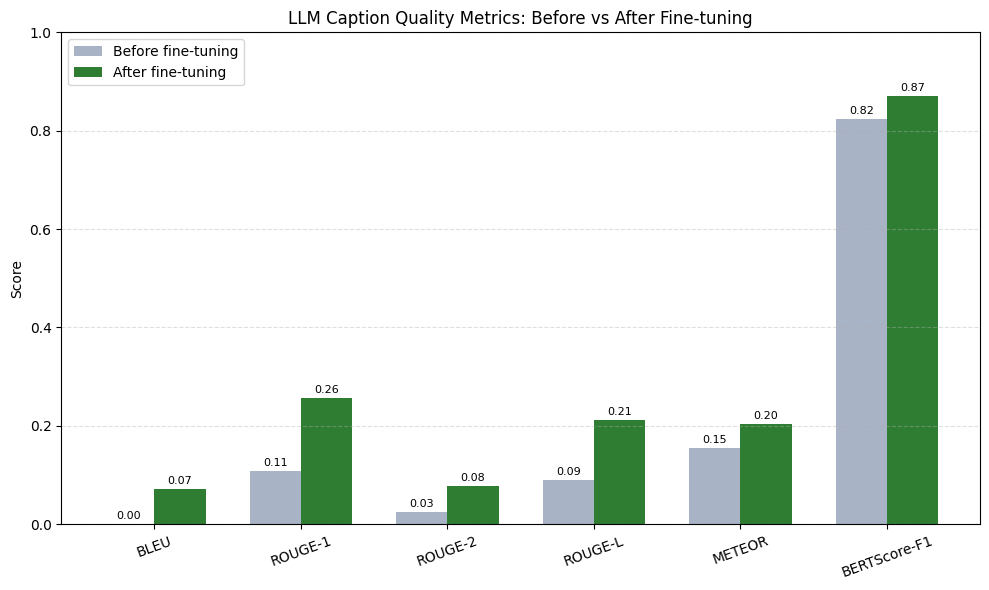

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metric_names = list(before_scores.keys())
before_values = [before_scores[m] for m in metric_names]
after_values = [after_scores[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, before_values, width, label="Before fine-tuning", color="#a8b3c5")
bars2 = ax.bar(x + width/2, after_values, width, label="After fine-tuning", color="#2e7d32")

ax.set_ylabel("Score")
ax.set_title("LLM Caption Quality Metrics: Before vs After Fine-tuning")
ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=20)
ax.legend()
ax.set_ylim(0, 1)
ax.bar_label(bars1, fmt="%.2f", padding=2, fontsize=8)
ax.bar_label(bars2, fmt="%.2f", padding=2, fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Next, the per-sample BERTScore F1 distribution, to see how consistently the fine-tuned model improves over the base model across individual radiographs.

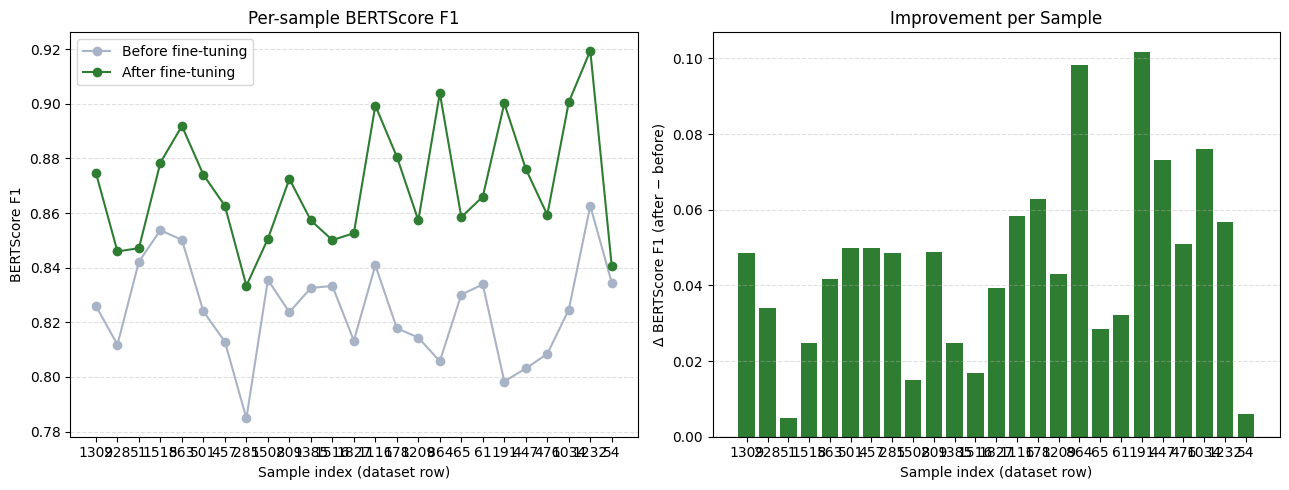

Average BERTScore F1 improvement after fine-tuning: +0.0454
Samples improved: 25 / 25


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: per-sample BERTScore F1, before vs after
sample_labels = [str(i) for i in eval_indices]
x = np.arange(len(sample_labels))
axes[0].plot(x, before_bert_f1, marker="o", label="Before fine-tuning", color="#a8b3c5")
axes[0].plot(x, after_bert_f1, marker="o", label="After fine-tuning", color="#2e7d32")
axes[0].set_xticks(x)
axes[0].set_xticklabels(sample_labels)
axes[0].set_xlabel("Sample index (dataset row)")
axes[0].set_ylabel("BERTScore F1")
axes[0].set_title("Per-sample BERTScore F1")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Right: distribution of the improvement (delta) per sample
colors = ["#2e7d32" if d >= 0 else "#c62828" for d in comparison_df["bertscore_f1_delta"]]
axes[1].bar(sample_labels, comparison_df["bertscore_f1_delta"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Sample index (dataset row)")
axes[1].set_ylabel("Δ BERTScore F1 (after − before)")
axes[1].set_title("Improvement per Sample")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

avg_delta = comparison_df["bertscore_f1_delta"].mean()
print(f"Average BERTScore F1 improvement after fine-tuning: {avg_delta:+.4f}")
print(f"Samples improved: {(comparison_df['bertscore_f1_delta'] > 0).sum()} / {len(comparison_df)}")

### Takeaways

- The grouped bar chart shows whether fine-tuning moved each corpus-level metric (BLEU, ROUGE,
  METEOR, BERTScore) in the right direction — for a radiology captioning task, BERTScore and
  ROUGE-L are usually more informative than BLEU, since exact n-gram overlap penalizes valid
  clinical rephrasings.
- The per-sample plot and delta chart make it easy to spot whether gains are consistent across
  the sample or driven by a few outliers — worth inspecting the `comparison_df` rows where the
  delta is negative to understand failure modes.
- For a more rigorous evaluation, increase `N_EVAL_SAMPLES` to cover more of the dataset (or a
  proper held-out test split, if one exists), and consider adding domain-specific metrics (e.g.
  clinical entity/finding overlap) on top of these general NLG metrics.

### Export the fine-tuned model
Save the fine-tuned model in GGUF format (quantized to 4-bit) so it can be used with llama.cpp-compatible inference engines.

In [ ]:
model.save_pretrained_gguf(
    "radiology_model_gguf",
    tokenizer,
    quantization_method = "q4_k_m",
)